# Imports

In [12]:
from utils import sql
from matplotlib import pyplot as plt

# Découverte de la table "visit_occurence"

In [7]:
visit_occurrence = sql("""
SELECT *
FROM omop.visit_occurrence
""")

visit_occurrence.head()

,visit_occurrence_id,person_id,visit_concept_id,visit_start_date,visit_start_datetime,visit_end_date,visit_end_datetime,visit_type_concept_id,provider_id,care_site_id,visit_source_value,visit_source_concept_id,admitted_from_concept_id,admitted_from_source_value,discharged_to_concept_id,discharged_to_source_value,preceding_visit_occurrence_id
0,98894,5752,9202,1992-05-12,1992-05-12 13:05:03,1992-05-12,1992-05-12 13:40:33,32817,None,None,wellness,0,None,None,None,None,None
1,98895,5751,9202,2020-07-04,2020-07-04 21:53:23,2020-07-04,2020-07-04 22:08:23,32817,None,None,wellness,0,None,None,None,None,None
2,98896,5754,9202,2016-08-04,2016-08-04 05:01:05,2016-08-04,2016-08-04 07:58:58,32817,None,None,ambulatory,0,None,None,None,None,None
3,98897,5753,9202,2024-09-07,2024-09-07 21:46:48,2024-09-07,2024-09-07 22:01:48,32817,None,None,wellness,0,None,None,None,None,None
4,98898,5755,9202,2021-04-20,2021-04-20 23:47:47,2021-04-21,2021-04-21 00:02:47,32817,None,None,wellness,0,None,None,None,None,None


In [8]:
visit_occurrence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   visit_occurrence_id            5728 non-null   int64         
 1   person_id                      5728 non-null   int64         
 2   visit_concept_id               5728 non-null   int64         
 3   visit_start_date               5728 non-null   object        
 4   visit_start_datetime           5728 non-null   datetime64[ns]
 5   visit_end_date                 5728 non-null   object        
 6   visit_end_datetime             5728 non-null   datetime64[ns]
 7   visit_type_concept_id          5728 non-null   int64         
 8   provider_id                    0 non-null      object        
 9   care_site_id                   0 non-null      object        
 10  visit_source_value             5728 non-null   object        
 11  visit_source_conc

Comme pour les patients, nous avons volontairement exclus du mapping certaines colonnes concernants les séjours : la GAM, l'établissement, les infos d'entrée/sortie.

In [4]:
visit_occurrence.describe()

,visit_occurrence_id,person_id,visit_concept_id,visit_start_datetime,visit_end_datetime,visit_type_concept_id,visit_source_concept_id
count,5728.000000,5728.000000,5.728000e+03,5728,5728,5728.0,5728.0
mean,101757.500000,5818.842004,8.514972e+04,2017-12-06 20:21:29.168645120,2017-12-07 00:44:30.572800256,32817.0,0.0
min,98894.000000,5751.000000,0.000000e+00,1930-07-06 00:13:34,1930-07-06 00:28:34,32817.0,0.0
25%,100325.750000,5793.000000,9.202000e+03,2017-10-27 23:45:43.750000128,2017-10-28 00:27:07,32817.0,0.0
50%,101757.500000,5824.000000,9.202000e+03,2020-10-12 11:51:50.500000,2020-10-12 12:29:20.500000,32817.0,0.0
75%,103189.250000,5849.000000,9.202000e+03,2023-05-22 05:31:55,2023-05-22 06:30:13,32817.0,0.0
max,104621.000000,5860.000000,4.289816e+07,2026-07-26 21:09:50,2026-07-26 21:24:50,32817.0,0.0
std,1653.675502,33.116237,1.790747e+06,NaN,NaN,0.0,0.0


### Types de séjours

In [19]:
visit_types = sql("""
SELECT
    c.concept_name,
    COUNT(*)
FROM omop.visit_occurrence v
JOIN omop.concept c
ON v.visit_concept_id = c.concept_id
GROUP BY c.concept_name
""")

visit_types

,concept_name,count
0,Home Visit,11
1,Inpatient Visit,74
2,No matching concept,17
3,Outpatient Visit,5159
4,Emergency Room Visit,457
5,Non-hospital institution Visit,10


### Nombre de visite par patients

In [15]:
visit_per_patient = sql("""
SELECT
    person_id,
    COUNT(*) nb
FROM omop.visit_occurrence
GROUP BY person_id
""")

visit_per_patient

,person_id,nb
0,5751,24
1,5752,21
2,5753,12
3,5754,14
4,5755,15
...,...,...
105,5856,45
106,5857,92
107,5858,321
108,5859,609


(array([92., 13.,  2.,  1.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([ 11. ,  70.8, 130.6, 190.4, 250.2, 310. , 369.8, 429.6, 489.4,
        549.2, 609. ]),
 <BarContainer object of 10 artists>)

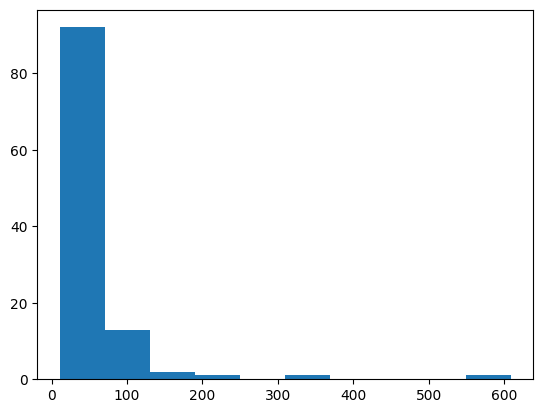

In [16]:
plt.hist(visit_per_patient["nb"])

On constate quelques valeurs extrêmes : un patient a 321 séjours puis un autre 609.

In [23]:
vpp_sorted = visit_per_patient.sort_values(by=["nb"], ascending = False)
vpp_sorted.head()

,person_id,nb
108,5859,609
107,5858,321
95,5846,243
96,5847,159
74,5825,134


Analyse pour les patients avec valeurs extrêmes :

In [28]:
visit_types_for_top_patients = sql("""
SELECT
    person_id,
    visit_source_value,
    COUNT(*) AS nb_sejours
FROM omop.visit_occurrence
WHERE person_id IN (
    5859,
    5858,
    5846,
    5847,
    5825
)
GROUP BY
    person_id,
    visit_source_value
ORDER BY
    person_id,
    nb_sejours DESC
""")

visit_types_for_top_patients

,person_id,visit_source_value,nb_sejours
0,5825,ambulatory,49
1,5825,outpatient,29
2,5825,urgentcare,25
3,5825,wellness,19
4,5825,emergency,9
5,5825,snf,1
6,5825,hospice,1
7,5825,inpatient,1
8,5846,ambulatory,76
9,5846,urgentcare,74


Lien avec les conditions :

In [31]:
conditions_for_top_patients = sql("""
SELECT
    v.person_id,
    v.visit_source_value,
    c2.concept_name AS condition_name,
    COUNT(*) AS nb
FROM omop.visit_occurrence v
JOIN omop.condition_occurrence c
ON c.visit_occurrence_id = v.visit_occurrence_id
JOIN omop.concept c2
ON c.condition_concept_id = c2.concept_id
WHERE v.person_id = 5859
GROUP BY
    v.person_id,
    v.visit_source_value,
    c2.concept_name
ORDER BY nb DESC;
""")

conditions_for_top_patients

,person_id,visit_source_value,condition_name,nb
0,5859,outpatient,Medication review due,12
1,5859,outpatient,Stress,6
2,5859,outpatient,Full-time employment,5
3,5859,outpatient,Limited social contact,5
4,5859,ambulatory,Gingival disease,4
5,5859,outpatient,Gingivitis,4
6,5859,ambulatory,Primary dental caries,3
7,5859,wellness,Medication review due,3
8,5859,outpatient,Social isolation,3
9,5859,urgentcare,Medication review due,3
